In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('features_v3_ohe_crop.csv')

In [2]:
X = df.drop(columns=['yield_log1p']) 
y = df['yield_log1p']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Split ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Split ---
X_train shape: (12922, 76)
X_test shape: (3231, 76)
y_train shape: (12922,)
y_test shape: (3231,)



--- Training Baseline Random Forest Regressor ---
Baseline model trained.

--- Evaluating Baseline Model ---
Baseline RMSE (log1p scale): 0.1847
Baseline R-squared (R²):     0.9559


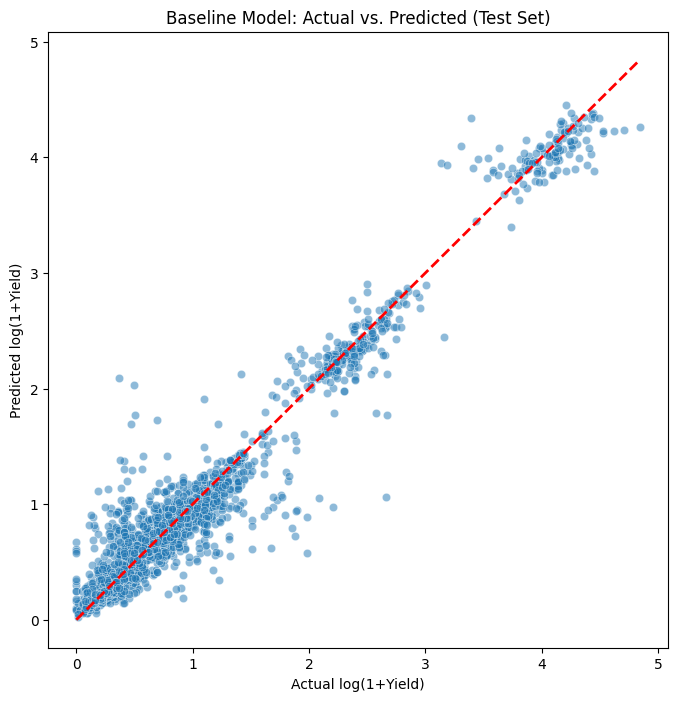

In [4]:
print("\n--- Training Baseline Random Forest Regressor ---")
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Use all CPU cores

rf_baseline.fit(X_train, y_train)
print("Baseline model trained.")



print("\n--- Evaluating Baseline Model ---")
y_pred_baseline = rf_baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline RMSE (log1p scale): {rmse_baseline:.4f}")
print(f"Baseline R-squared (R²):     {r2_baseline:.4f}")

# Optional: Visualize predictions vs actuals
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_baseline, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # y=x line
plt.xlabel("Actual log(1+Yield)")
plt.ylabel("Predicted log(1+Yield)")
plt.title("Baseline Model: Actual vs. Predicted (Test Set)")
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming rf_baseline is your trained RandomForestRegressor from Task 6
# Assuming X_train is available from Task 6

importances = rf_baseline.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easier handling
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("--- Top 20 Feature Importances ---")
print(feature_importance_df.head(20))

--- Top 20 Feature Importances ---
              feature  importance
64     crop_sugarcane    0.541516
63        crop_potato    0.151185
70  crop_sweet_potato    0.052562
72         crop_onion    0.049306
1                area    0.021113
3     total_precip_mm    0.020782
55          crop_rice    0.020518
0                year    0.017275
60         crop_maize    0.016572
75         crop_other    0.015673
73        crop_garlic    0.015459
57     crop_groundnut    0.014711
66         crop_wheat    0.010048
2          avg_temp_c    0.009346
49      season_Autumn    0.007291
6              mean_p    0.005186
68  crop_dry_chillies    0.002391
61          crop_ragi    0.001715
71     crop_sunflower    0.001236
50      season_Kharif    0.001057


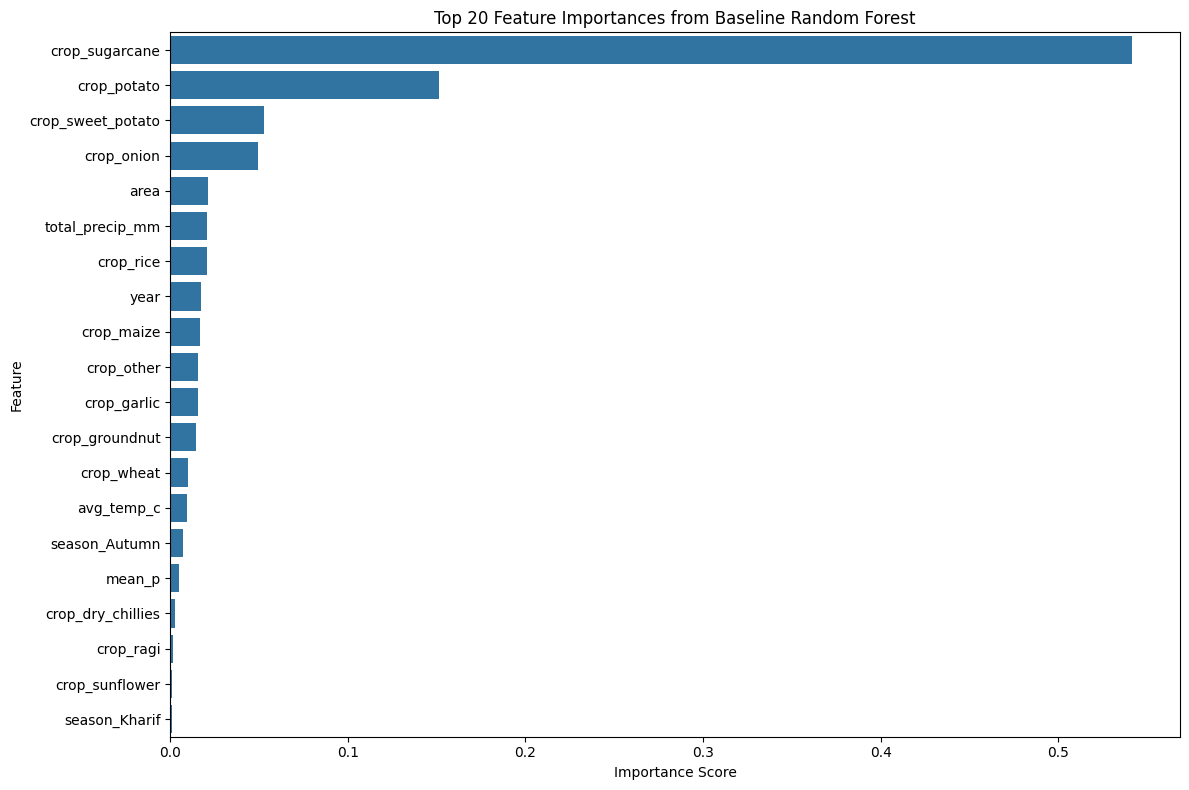

In [6]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Baseline Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- Training LightGBM Regressor (Defaults) ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 955
[LightGBM] [Info] Number of data points in the train set: 12922, number of used features: 76
[LightGBM] [Info] Start training from score 0.819346
LightGBM model trained.

--- Evaluating LightGBM Model ---
LightGBM RMSE (log1p scale): 0.1851
LightGBM R-squared (R²):     0.9557


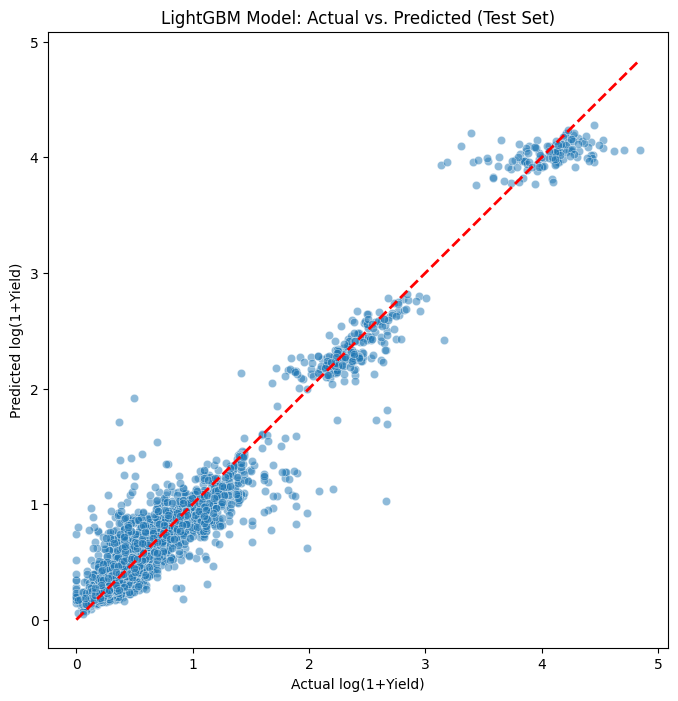

In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, y_test are loaded

print("\n--- Training LightGBM Regressor (Defaults) ---")
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
print("LightGBM model trained.")

print("\n--- Evaluating LightGBM Model ---")
y_pred_lgbm = lgbm.predict(X_test)

rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM RMSE (log1p scale): {rmse_lgbm:.4f}")
print(f"LightGBM R-squared (R²):     {r2_lgbm:.4f}")

# Visualize predictions vs actuals for LGBM
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_lgbm, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual log(1+Yield)")
plt.ylabel("Predicted log(1+Yield)")
plt.title("LightGBM Model: Actual vs. Predicted (Test Set)")
plt.show()


--- Training Tuned Random Forest Regressor ---
Tuned Random Forest model trained.

--- Evaluating Tuned Random Forest Model ---
Tuned RF RMSE (log1p scale): 0.1860
Tuned RF R-squared (R²):     0.9553


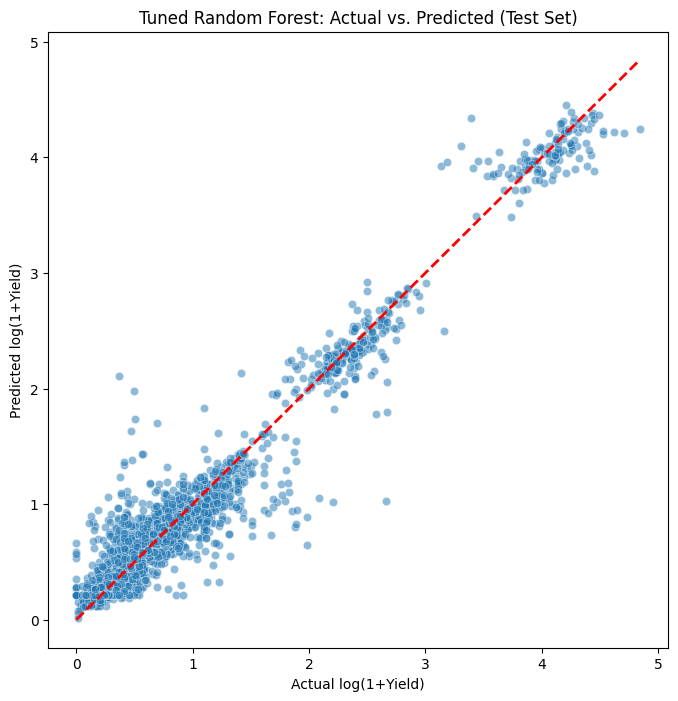

In [8]:
from sklearn.ensemble import RandomForestRegressor

print("\n--- Training Tuned Random Forest Regressor ---")
# Try more trees and slightly deeper max_depth
rf_tuned = RandomForestRegressor(n_estimators=300, # More trees
                                 max_depth=20,     # Allow deeper trees (default can be None)
                                 random_state=42,
                                 n_jobs=-1)

rf_tuned.fit(X_train, y_train)
print("Tuned Random Forest model trained.")

print("\n--- Evaluating Tuned Random Forest Model ---")
y_pred_rf_tuned = rf_tuned.predict(X_test)

rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned RF RMSE (log1p scale): {rmse_rf_tuned:.4f}")
print(f"Tuned RF R-squared (R²):     {r2_rf_tuned:.4f}")

# Visualize predictions vs actuals for Tuned RF
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_rf_tuned, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual log(1+Yield)")
plt.ylabel("Predicted log(1+Yield)")
plt.title("Tuned Random Forest: Actual vs. Predicted (Test Set)")
plt.show()